# 08. 모델링 v2 — 클러스터 기반 입양률 결정요인 분석

**목적:** 보호소를 운영+성과 변수로 유형화(1단계)한 뒤, 각 클러스터 내에서 입양률 결정요인을 분석(2단계)하여 **클러스터별 차별적 패턴**을 발견한다.

**핵심 질문:** "어떤 유형의 보호소에서 어떤 요인이 입양률에 중요한가?"

**입력:** `02_outputs/data/shelter_full_merged.csv` (564행, 32컬럼)
**참조:** `02_outputs/data/shelter_clustering_result.csv` (v1 클러스터 라벨)

**방법론:**
1. **1단계 — 프로파일링 클러스터링:** 성과 4개 + 운영/인프라 4개 = 8개 피처로 K-Means
2. **2단계 — 입양률 회귀:** 전체 + 클러스터별 LightGBM 회귀 → SHAP 비교
3. **2-Track 검증:** Track A(564개, 결측 대체) vs Track B(333개, 인프라 매칭만) → ARI 비교

**v1 대비 차별점:**
- 클러스터링 피처 4개 → 8개 (운영 규모, 인프라, 동물 구성 추가)
- 보호소 수준 회귀 분석 (v1의 개체 수준과 상호보완)
- 클러스터 간 SHAP 비교로 차별적 결정요인 도출

## 1. 환경 설정

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             adjusted_rand_score, mean_absolute_error, r2_score)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import KFold, cross_val_predict

import lightgbm as lgb
import shap
import pickle

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Apple SD Gothic Neo'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# 경로 설정
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'modeling_v2')
MODEL_DIR = os.path.join(BASE_DIR, '06_models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# 시각화 색상 팔레트
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

print(f'BASE_DIR: {BASE_DIR}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'MODEL_DIR: {MODEL_DIR}')

BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
FIG_DIR : /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/modeling_v2
MODEL_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/06_models


## 2. 데이터 로드 및 피처 엔지니어링

### 2-1. 데이터 로드 및 기초 정보

In [2]:
# 주 데이터: 보호소 수준 통합 데이터
df = pd.read_csv(os.path.join(DATA_DIR, 'shelter_full_merged.csv'))
print(f'보호소 수: {len(df)}')
print(f'컬럼 수: {len(df.columns)}')
print(f'\n컬럼 목록: {list(df.columns)}')

# 기초 통계
print(f'\n=== 기초 통계 ===')
display(df.describe().round(2))

# 결측치 현황
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\n=== 결측치 현황 ===')
if len(missing) > 0:
    for col, cnt in missing.items():
        print(f'  {col}: {cnt}개 ({cnt/len(df)*100:.1f}%)')
else:
    print('  결측치 없음')

# v1 클러스터 라벨 로드 (ARI 비교용)
df_v1 = pd.read_csv(os.path.join(DATA_DIR, 'shelter_clustering_result.csv'))
print(f'\nv1 클러스터 라벨 로드 완료: {len(df_v1)}개 보호소')
print(f'v1 클러스터 분포:\n{df_v1["cluster_label"].value_counts()}')

보호소 수: 564
컬럼 수: 32

컬럼 목록: ['보호소명', '시도', '시군구', '총보호건수', '입양건수', '자연사건수', '안락사건수', '반환건수', '평균보호기간', '개비율', '고양이비율', '입양률', '안락사율', '자연사율', '센터명', '센터유형', '수의사인원수', '사양관리사인원수', '총인력', '수의사유무', '운영구분', '운영세부유형', '규모구간', '총인구수', '세대수', '면적_km2', '인구밀도', '재정자립도', '고령화율', '1인가구비율', '고령화율_시군구', '1인가구비율_시군구']

=== 기초 통계 ===


,총보호건수,입양건수,자연사건수,안락사건수,반환건수,평균보호기간,개비율,고양이비율,입양률,안락사율,...,수의사유무,총인구수,세대수,면적_km2,인구밀도,재정자립도,고령화율,1인가구비율,고령화율_시군구,1인가구비율_시군구
count,564.00,564.00,564.00,564.00,564.00,564.00,564.00,564.00,564.00,564.00,...,564.00,564.00,564.00,560.00,560.00,555.00,564.00,564.00,562.00,564.00
mean,1400.48,437.26,410.40,318.99,170.47,10.54,66.11,28.07,36.99,18.87,...,0.45,290688.92,130806.51,376.99,4682.85,19.61,21.18,34.66,21.18,34.66
std,2372.76,706.90,695.95,974.82,297.75,4.77,31.49,29.29,24.19,21.72,...,0.50,274279.17,118648.48,351.73,6126.75,10.12,8.52,5.47,8.54,5.46
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,9122.17,5458.00,2.83,16.61,5.49,9.29,18.20,9.29,18.20
25%,52.75,16.00,4.00,1.00,6.00,10.05,43.18,1.60,20.27,0.39,...,0.00,70176.16,35188.88,42.48,131.17,11.02,15.06,30.55,15.06,30.55
50%,658.50,192.00,122.00,63.50,48.50,10.55,74.30,19.00,32.03,12.51,...,0.00,219553.00,104397.19,253.99,1112.38,17.33,17.56,35.19,17.55,35.19
75%,1885.50,549.00,508.25,344.50,193.75,10.67,94.34,47.59,50.00,29.60,...,1.00,416336.00,185206.17,660.75,8872.73,25.06,27.48,38.08,27.48,38.08
max,34673.00,5822.00,6478.00,19506.00,2047.00,116.83,100.00,100.00,100.00,100.00,...,1.00,1190913.83,521647.83,1820.34,25537.07,53.30,44.09,54.45,44.09,54.45



=== 결측치 현황 ===
  센터명: 239개 (42.4%)
  센터유형: 239개 (42.4%)
  수의사인원수: 239개 (42.4%)
  사양관리사인원수: 239개 (42.4%)
  재정자립도: 9개 (1.6%)
  면적_km2: 4개 (0.7%)
  인구밀도: 4개 (0.7%)
  고령화율_시군구: 2개 (0.4%)

v1 클러스터 라벨 로드 완료: 564개 보호소
v1 클러스터 분포:
cluster_label
C3: 고자연사형    221
C1: 적극입양형    177
C2: 고안락사형    113
C0: 균형관리형     53
Name: count, dtype: int64


### 2-2. 파생변수 생성

In [3]:
# --- 파생변수 생성 ---

# 1) 로그 변환 (우측 꼬리 분포 완화)
df['log_총보호건수'] = np.log1p(df['총보호건수'])
df['log_총인력'] = np.log1p(df['총인력'])

# 2) 반환률
df['반환률'] = df['반환건수'] / df['총보호건수'] * 100

# 3) 인프라정보유무 (센터명이 있으면 인프라 정보 보유)
df['인프라정보유무'] = df['센터명'].notna().astype(int)
print(f'인프라정보유무 분포:\n{df["인프라정보유무"].value_counts()}')
print(f'  → 인프라 보유: {df["인프라정보유무"].sum()}개, 미보유: {(1-df["인프라정보유무"]).sum():.0f}개')

# 4) 결측치 처리: 수의사인원수, 사양관리사인원수, 총인력
#    → 시군구 중앙값 대체 → 전체 중앙값 대체
infra_cols = ['수의사인원수', '사양관리사인원수', '총인력']
for col in infra_cols:
    before_null = df[col].isnull().sum()
    # 시군구 중앙값 대체
    sigungu_median = df.groupby('시군구')[col].transform('median')
    df[col] = df[col].fillna(sigungu_median)
    # 전체 중앙값 대체 (시군구에도 없는 경우)
    df[col] = df[col].fillna(df[col].median())
    after_null = df[col].isnull().sum()
    print(f'{col}: 결측 {before_null}→{after_null}')

# log_총인력 재계산 (결측 대체 후)
df['log_총인력'] = np.log1p(df['총인력'])

# 5) 수의사유무 결측 처리 (0으로)
df['수의사유무'] = df['수의사유무'].fillna(0).astype(int)

# 6) 인력밀도 = 총인력 / max(1, 총보호건수/1000)
df['인력밀도'] = df['총인력'] / np.maximum(1, df['총보호건수'] / 1000)

# 7) 사회경제 변수 결측 처리 (중앙값)
socio_cols = ['인구밀도', '재정자립도', '고령화율', '1인가구비율']
for col in socio_cols:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'{col}: 결측 {n_null}개 → 중앙값 대체')

# 8) 센터유형 One-Hot Encoding
df['센터유형_clean'] = df['센터유형'].fillna('미상')
ohe = pd.get_dummies(df['센터유형_clean'], prefix='센터유형')
df = pd.concat([df, ohe], axis=1)
print(f'\n센터유형 분포:\n{df["센터유형_clean"].value_counts()}')

# 결측치 최종 확인
final_missing = df.isnull().sum()
final_missing = final_missing[final_missing > 0]
if len(final_missing) > 0:
    print(f'\n⚠ 잔여 결측치: {dict(final_missing)}')
else:
    print(f'\n✓ 결측치 처리 완료 — 잔여 결측 없음')

print(f'\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열')

인프라정보유무 분포:
인프라정보유무
1    325
0    239
Name: count, dtype: int64
  → 인프라 보유: 325개, 미보유: 239개
수의사인원수: 결측 239→0
사양관리사인원수: 결측 239→0
총인력: 결측 0→0
인구밀도: 결측 4개 → 중앙값 대체
재정자립도: 결측 9개 → 중앙값 대체

센터유형 분포:
센터유형_clean
미상      239
법인      138
동물병원    108
단체       58
개인       21
Name: count, dtype: int64

⚠ 잔여 결측치: {'센터명': np.int64(239), '센터유형': np.int64(239), '면적_km2': np.int64(4), '고령화율_시군구': np.int64(2)}

최종 데이터: 564행 × 43열


### 2-3. 분석 변수 구분

In [4]:
# --- 분석 변수 정의 ---

# 클러스터링 피처 (8개)
CLUSTER_FEATURES = [
    '입양률', '안락사율', '자연사율', '평균보호기간',
    'log_총보호건수', '수의사유무', 'log_총인력', '개비율'
]

# 회귀 독립변수 (~15개)
# 센터유형 OHE 컬럼 자동 탐지
ohe_cols = [c for c in df.columns if c.startswith('센터유형_') and c != '센터유형_clean']

REGRESSION_FEATURES = [
    # 운영/인프라
    'log_총보호건수', '수의사유무', 'log_총인력', '개비율',
    '반환률', '인력밀도', '인프라정보유무',
    # 보호 결과 (입양률 제외 — 종속변수)
    '안락사율', '자연사율', '평균보호기간',
    # 사회경제
    '인구밀도', '재정자립도', '고령화율', '1인가구비율',
] + ohe_cols

# 종속변수
TARGET = '입양률'

# 사후 해석 변수
SOCIO_VARS = ['인구밀도', '재정자립도', '고령화율', '1인가구비율',
              '고령화율_시군구', '1인가구비율_시군구']

# 변수 구분표 출력
print('=' * 60)
print('분석 변수 구분')
print('=' * 60)
print(f'\n[클러스터링 피처] ({len(CLUSTER_FEATURES)}개):')
for f in CLUSTER_FEATURES:
    desc = '성과' if f in ['입양률','안락사율','자연사율','평균보호기간'] else '운영/인프라'
    v1 = 'v1 동일' if f in ['입양률','안락사율','자연사율','평균보호기간'] else '★신규'
    print(f'  • {f} [{desc}] {v1}')

print(f'\n[회귀 독립변수] ({len(REGRESSION_FEATURES)}개):')
for f in REGRESSION_FEATURES:
    print(f'  • {f}')

print(f'\n[종속변수]: {TARGET}')
print(f'\n[사후 해석 변수] ({len(SOCIO_VARS)}개): {SOCIO_VARS}')

분석 변수 구분

[클러스터링 피처] (8개):
  • 입양률 [성과] v1 동일
  • 안락사율 [성과] v1 동일
  • 자연사율 [성과] v1 동일
  • 평균보호기간 [성과] v1 동일
  • log_총보호건수 [운영/인프라] ★신규
  • 수의사유무 [운영/인프라] ★신규
  • log_총인력 [운영/인프라] ★신규
  • 개비율 [운영/인프라] ★신규

[회귀 독립변수] (19개):
  • log_총보호건수
  • 수의사유무
  • log_총인력
  • 개비율
  • 반환률
  • 인력밀도
  • 인프라정보유무
  • 안락사율
  • 자연사율
  • 평균보호기간
  • 인구밀도
  • 재정자립도
  • 고령화율
  • 1인가구비율
  • 센터유형_개인
  • 센터유형_단체
  • 센터유형_동물병원
  • 센터유형_미상
  • 센터유형_법인

[종속변수]: 입양률

[사후 해석 변수] (6개): ['인구밀도', '재정자립도', '고령화율', '1인가구비율', '고령화율_시군구', '1인가구비율_시군구']


## 3. 1단계 — 보호소 프로파일링 클러스터링

### 3-1. 클러스터링 피처 선택 근거

| 변수 | 구분 | v1 대비 | 선택 근거 |
|------|------|---------|-----------|
| 입양률 | 성과 | v1 동일 | 핵심 성과 지표 |
| 안락사율 | 성과 | v1 동일 | 보호소 운영 방침 반영 |
| 자연사율 | 성과 | v1 동일 | 의료/보호 환경 품질 proxy |
| 평균보호기간 | 성과 | v1 동일 | 보호 역량/체류 시간 |
| log_총보호건수 | 운영 규모 | **★신규** | 보호소 규모 → 입양 자원과 연결 |
| 수의사유무 | 인프라 | **★신규** | 의료 인프라 유무 |
| log_총인력 | 인프라 | **★신규** | 인력 투입 수준 |
| 개비율 | 동물 구성 | **★신규** | 개/고양이 비율 → 입양 패턴 상이 |

**v1 대비 변화:** 성과 변수 4개만 사용 → 성과 4개 + 운영/인프라 4개 = 8개로 확장하여 보호소를 더 다면적으로 유형화

### 3-2. 전처리: 이상치 클리핑 + RobustScaler

=== 이상치 클리핑 (1~99 퍼센타일) ===
  자연사율: 6개 클리핑 (범위: 0.00~80.46)
  평균보호기간: 12개 클리핑 (범위: 6.45~15.64)
  log_총보호건수: 6개 클리핑 (범위: 0.69~9.20)
  log_총인력: 6개 클리핑 (범위: 0.00~2.59)

스케일링 완료: (564, 8)


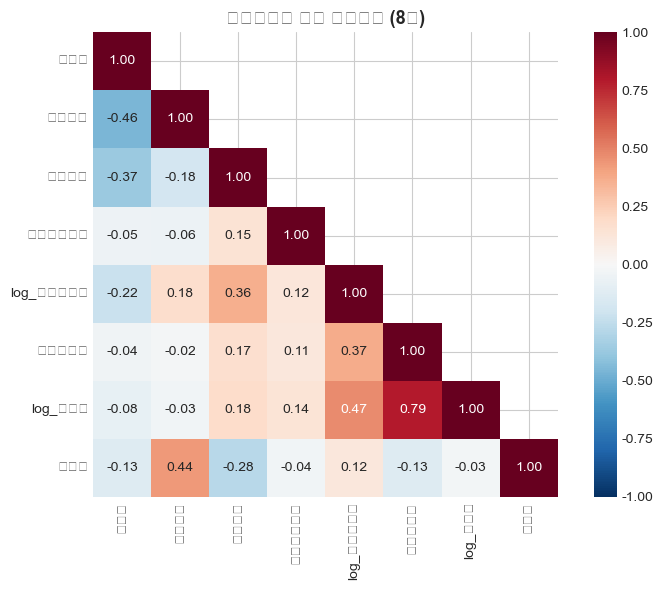


⚠ 높은 상관관계 (|r| > 0.6):
  수의사유무 ↔ log_총인력: r=0.791


In [5]:
# 클러스터링 피처 추출
X_cluster = df[CLUSTER_FEATURES].copy()

# 이상치 클리핑 (99퍼센타일)
clip_info = []
for col in CLUSTER_FEATURES:
    if col in ['수의사유무']:  # 이진 변수는 클리핑 불필요
        continue
    p99 = X_cluster[col].quantile(0.99)
    p01 = X_cluster[col].quantile(0.01)
    n_clipped = ((X_cluster[col] > p99) | (X_cluster[col] < p01)).sum()
    if n_clipped > 0:
        X_cluster[col] = X_cluster[col].clip(lower=p01, upper=p99)
        clip_info.append(f'  {col}: {n_clipped}개 클리핑 (범위: {p01:.2f}~{p99:.2f})')

print('=== 이상치 클리핑 (1~99 퍼센타일) ===')
for info in clip_info:
    print(info)

# RobustScaler (이상치에 강건)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'\n스케일링 완료: {X_scaled.shape}')

# 피처 상관행렬 히트맵
fig, ax = plt.subplots(figsize=(8, 6))
corr = X_cluster.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask, square=True)
ax.set_title('클러스터링 피처 상관행렬 (8개)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_feature_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

# 높은 상관관계 경고
high_corr = []
for i in range(len(CLUSTER_FEATURES)):
    for j in range(i+1, len(CLUSTER_FEATURES)):
        r = abs(corr.iloc[i, j])
        if r > 0.6:
            high_corr.append((CLUSTER_FEATURES[i], CLUSTER_FEATURES[j], corr.iloc[i, j]))
if high_corr:
    print('\n⚠ 높은 상관관계 (|r| > 0.6):')
    for f1, f2, r in high_corr:
        print(f'  {f1} ↔ {f2}: r={r:.3f}')
else:
    print('\n✓ 다중공선성 우려 없음 (모든 |r| ≤ 0.6)')

### 3-3. 최적 K 결정 (K=2~8)

K=2: Silhouette=0.4934, CH=287.8, 최소클러스터=65개
K=3: Silhouette=0.5253, CH=338.8, 최소클러스터=26개


K=4: Silhouette=0.2624, CH=306.0, 최소클러스터=26개
K=5: Silhouette=0.2342, CH=278.1, 최소클러스터=26개


K=6: Silhouette=0.2248, CH=251.8, 최소클러스터=26개
K=7: Silhouette=0.2342, CH=236.4, 최소클러스터=24개
K=8: Silhouette=0.2256, CH=222.5, 최소클러스터=25개


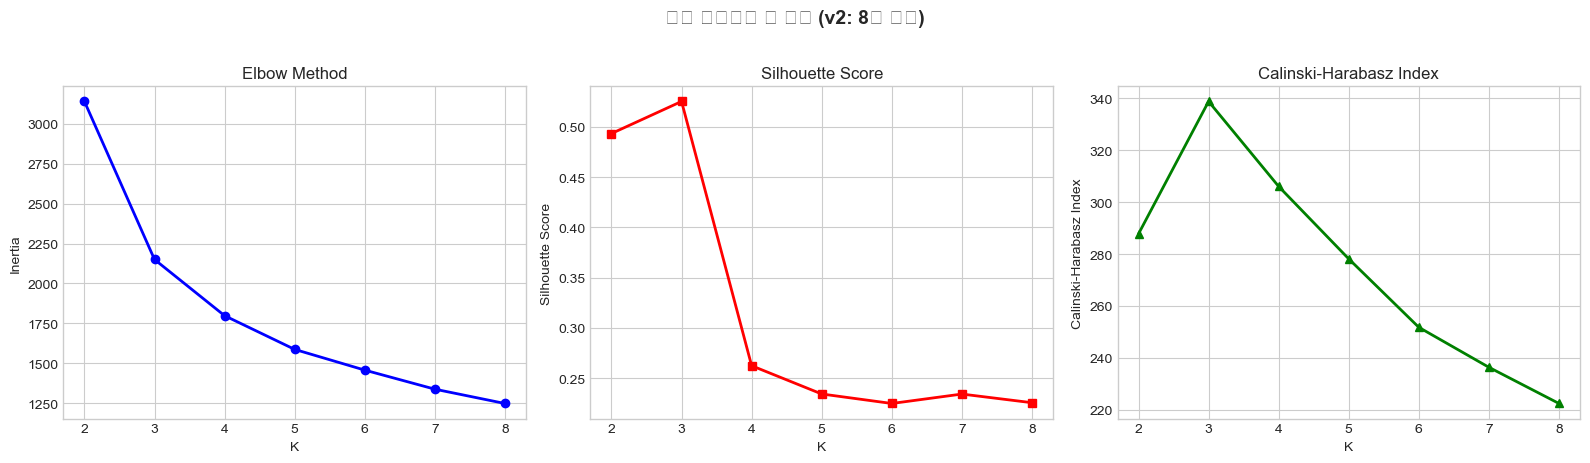


→ K=4 선택 (v1 대비 ARI 비교, 해석 최적)
  Silhouette=0.2624, 최소 클러스터=26개
  ⚠ 최소 클러스터 26개 < 40 → 해당 클러스터는 2단계 회귀 대신 기술통계만 수행


In [6]:
K_range = range(2, 9)
inertias, sil_scores, ch_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    min_size = pd.Series(labels).value_counts().min()
    print(f'K={k}: Silhouette={sil_scores[-1]:.4f}, CH={ch_scores[-1]:.1f}, '
          f'최소클러스터={min_size}개')

# 3x1 서브플롯
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 'rs-', linewidth=2, markersize=6)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_range))

axes[2].plot(list(K_range), ch_scores, 'g^-', linewidth=2, markersize=6)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].set_xticks(list(K_range))

plt.suptitle('최적 클러스터 수 결정 (v2: 8개 피처)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'optimal_k_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

# K=4 선택 (v1 클러스터링과 동일 K, ARI 비교 가능)
# v1에서 K=4, 최소 53개(균형관리형) → K=4가 해석에 최적
OPTIMAL_K = 4
idx_4 = list(K_range).index(4)
km_4 = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=500)
labels_4 = km_4.fit_predict(X_scaled)
min_sz_4 = pd.Series(labels_4).value_counts().min()
print(f'\n→ K=4 선택 (v1 대비 ARI 비교, 해석 최적)')
print(f'  Silhouette={sil_scores[idx_4]:.4f}, 최소 클러스터={min_sz_4}개')
if min_sz_4 < 40:
    print(f'  ⚠ 최소 클러스터 {min_sz_4}개 < 40 → 해당 클러스터는 2단계 회귀 대신 기술통계만 수행')


### 3-4. K-Means 클러스터링 실행

In [7]:
kmeans_v2 = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
df['cluster_v2'] = kmeans_v2.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['cluster_v2'])
ch = calinski_harabasz_score(X_scaled, df['cluster_v2'])

print(f'=== K-Means 클러스터링 결과 (K={OPTIMAL_K}) ===')
print(f'Silhouette Score: {sil:.4f}')
print(f'Calinski-Harabasz Index: {ch:.1f}')
print(f'\n클러스터별 보호소 수:')

# 개별 Silhouette Score
from sklearn.metrics import silhouette_samples
sil_samples = silhouette_samples(X_scaled, df['cluster_v2'])
df['silhouette'] = sil_samples

for c in sorted(df['cluster_v2'].unique()):
    n = (df['cluster_v2'] == c).sum()
    avg_sil = sil_samples[df['cluster_v2'] == c].mean()
    print(f'  클러스터 {c}: {n}개 (Silhouette={avg_sil:.4f})')

=== K-Means 클러스터링 결과 (K=4) ===
Silhouette Score: 0.2624
Calinski-Harabasz Index: 306.0

클러스터별 보호소 수:
  클러스터 0: 319개 (Silhouette=0.2409)
  클러스터 1: 60개 (Silhouette=0.5241)
  클러스터 2: 26개 (Silhouette=0.4605)
  클러스터 3: 159개 (Silhouette=0.1743)


### 3-5. 클러스터 프로파일링 및 자동 라벨링

In [8]:
# 클러스터별 프로파일 (평균 ± 표준편차)
profile_features = CLUSTER_FEATURES + ['반환률', '인력밀도', '총보호건수']
profile = df.groupby('cluster_v2')[profile_features].agg(['mean', 'std']).round(2)
print('=== 클러스터 프로파일 (평균 ± 표준편차) ===')
display(profile)

# 간결 요약
summary = df.groupby('cluster_v2')[CLUSTER_FEATURES].mean().round(2)
summary['보호소수'] = df.groupby('cluster_v2').size().values
summary['총보호건수_평균'] = df.groupby('cluster_v2')['총보호건수'].mean().round(0).values
print('\n=== 간결 요약 ===')
display(summary)

# 자동 라벨링
cluster_means = df.groupby('cluster_v2')[CLUSTER_FEATURES].mean()
v2_labels = {}

for c in sorted(df['cluster_v2'].unique()):
    row = cluster_means.loc[c]
    # 순위 기반 라벨링
    adoption_rank = cluster_means['입양률'].rank(ascending=False)[c]
    euthanasia_rank = cluster_means['안락사율'].rank(ascending=False)[c]
    natural_rank = cluster_means['자연사율'].rank(ascending=False)[c]
    scale_rank = cluster_means['log_총보호건수'].rank(ascending=False)[c]

    if adoption_rank == 1:
        label = '고입양형'
    elif euthanasia_rank == 1:
        label = '고안락사형'
    elif natural_rank == 1:
        label = '고자연사형'
    elif scale_rank == 1:
        label = '대규모운영형'
    else:
        label = '균형관리형'
    v2_labels[c] = f'C{c}: {label}'

df['cluster_v2_label'] = df['cluster_v2'].map(v2_labels)

print('\n=== 클러스터 라벨 ===')
for c, label in v2_labels.items():
    n = (df['cluster_v2'] == c).sum()
    m = cluster_means.loc[c]
    print(f'  {label} ({n}개)')
    print(f'    입양률={m["입양률"]:.1f}%, 안락사율={m["안락사율"]:.1f}%, '
          f'자연사율={m["자연사율"]:.1f}%, log_총보호건수={m["log_총보호건수"]:.2f}')

# 대표 보호소 Top 3
print('\n=== 클러스터별 대표 보호소 (규모 상위 3) ===')
for c in sorted(df['cluster_v2'].unique()):
    sub = df[df['cluster_v2'] == c].nlargest(3, '총보호건수')
    print(f'\n--- {v2_labels[c]} ---')
    display(sub[['보호소명', '시도', '총보호건수', '입양률', '안락사율', '자연사율',
                 '수의사유무', '총인력']].reset_index(drop=True))

=== 클러스터 프로파일 (평균 ± 표준편차) ===


입양률          안락사율          자연사율        평균보호기간        log_총보호건수  \
             mean    std   mean    std   mean    std   mean    std      mean   
cluster_v2                                                                     
0           26.10  12.44  25.16  22.02  32.47  19.45  10.49   0.47      6.80   
1           40.61  25.39  24.88  25.72  10.88  12.03   7.18   1.21      4.54   
2           37.81  26.85  18.86  23.35  21.48  21.15  18.86  20.10      5.68   
3           57.36  27.52   4.00   7.47  11.76  13.21  10.54   0.53      3.71   

                  ... log_총인력          개비율           반환률         인력밀도        \
             std  ...    mean   std   mean    std   mean    std  mean   std   
cluster_v2        ...                                                         
0           1.81  ...    1.13  0.85  67.57  26.99  11.66   9.31  1.84  2.30   
1           2.30  ...    0.47  0.75  76.84  30.36  15.26  17.74  1.04  2.34   
2           2.37  ...    1.23  0.75  77.81  30.54   9.53   9.82  2.63  2.78   
3           2.23  ...    0.41  0.68  57.20  37.76  17.32  24.11  1.06  2.92   

              총보호건수           
               mean      std  
cluster_v2                    
0           2125.89  2851.80  
1            578.42  1012.90  
2           1141.88  1485.97  
3            297.60   637.44  

[4 rows x 22 columns]


=== 간결 요약 ===


,입양률,안락사율,자연사율,평균보호기간,log_총보호건수,수의사유무,log_총인력,개비율,보호소수,총보호건수_평균
cluster_v2,,,,,,,,,,
0,26.10,25.16,32.47,10.49,6.80,0.59,1.13,67.57,319,2126.0
1,40.61,24.88,10.88,7.18,4.54,0.23,0.47,76.84,60,578.0
2,37.81,18.86,21.48,18.86,5.68,0.58,1.23,77.81,26,1142.0
3,57.36,4.00,11.76,10.54,3.71,0.23,0.41,57.20,159,298.0



=== 클러스터 라벨 ===
  C0: 고안락사형 (319개)
    입양률=26.1%, 안락사율=25.2%, 자연사율=32.5%, log_총보호건수=6.80
  C1: 균형관리형 (60개)
    입양률=40.6%, 안락사율=24.9%, 자연사율=10.9%, log_총보호건수=4.54
  C2: 균형관리형 (26개)
    입양률=37.8%, 안락사율=18.9%, 자연사율=21.5%, log_총보호건수=5.68
  C3: 고입양형 (159개)
    입양률=57.4%, 안락사율=4.0%, 자연사율=11.8%, log_총보호건수=3.71

=== 클러스터별 대표 보호소 (규모 상위 3) ===

--- C0: 고안락사형 ---


...

,보호소명,시도,총보호건수,입양률,안락사율,자연사율,수의사유무,총인력
0,서산시 동물보호센터,충청남도,3946,22.93,44.45,16.52,1,5.0
1,금일동물보호센터,충청남도,3829,48.42,11.28,23.77,0,0.0
2,정선가축병원,강원도,3809,38.65,36.02,23.44,1,5.0



--- C2: 균형관리형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,수의사유무,총인력
0,한국야생동물보호협회,경기도,6322,26.16,22.11,17.45,1,5.0
1,부안군 동물보호센터,전라북도,3452,31.78,10.43,35.63,1,3.0
2,전북말산업복합센터,전라북도,3058,55.89,5.82,23.05,1,5.0



--- C3: 고입양형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,수의사유무,총인력
0,중부벳동물병원,충청남도,4691,68.17,9.15,8.19,0,0.0
1,(구)민간동물보호소,충청남도,2795,48.80,4.51,25.87,0,0.0
2,하남동물병원,경기도,2671,62.07,4.75,16.96,0,0.0


### 3-6. v1 클러스터와 ARI 비교

In [9]:
# v1 클러스터 라벨 병합
df_compare = df[['보호소명', 'cluster_v2']].merge(
    df_v1[['보호소명', 'cluster']].rename(columns={'cluster': 'cluster_v1'}),
    on='보호소명', how='inner'
)

ari = adjusted_rand_score(df_compare['cluster_v1'], df_compare['cluster_v2'])
print(f'=== v1 vs v2 클러스터 비교 ===')
print(f'비교 보호소 수: {len(df_compare)}')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'  → {"높은 일치도 (>0.5)" if ari > 0.5 else "의미있는 변화 (<0.5) — 피처 확장 효과"}')

# 교차표
ct = pd.crosstab(
    df_compare['cluster_v1'].map(lambda x: df_v1.set_index('cluster')['cluster_label'].drop_duplicates().to_dict().get(x, f'v1_C{x}')),
    df_compare['cluster_v2'].map(v2_labels),
    margins=True
)
print(f'\n교차표 (v1 행 × v2 열):')
display(ct)

=== v1 vs v2 클러스터 비교 ===
비교 보호소 수: 1734
Adjusted Rand Index (ARI): 0.2165
  → 의미있는 변화 (<0.5) — 피처 확장 효과



교차표 (v1 행 × v2 열):


cluster_v2,C0: 고안락사형,C1: 균형관리형,C2: 균형관리형,C3: 고입양형,All
cluster_v1,,,,,
C0: 균형관리형,29,56,3,7,95
C1: 적극입양형,59,4,12,147,222
C2: 고안락사형,334,16,28,3,381
C3: 고자연사형,866,27,78,65,1036
All,1288,103,121,222,1734


### 3-7. PCA 2D 산점도 + Loading 해석

PCA 설명 분산: PC1=0.632, PC2=0.124
누적: 0.757

PCA 로딩:


,PC1,PC2
입양률,-0.025,0.677
안락사율,-0.020,-0.458
자연사율,0.055,-0.323
평균보호기간,0.996,0.050
log_총보호건수,0.043,-0.394
수의사유무,0.029,-0.124
log_총인력,0.037,-0.163
개비율,-0.012,-0.163


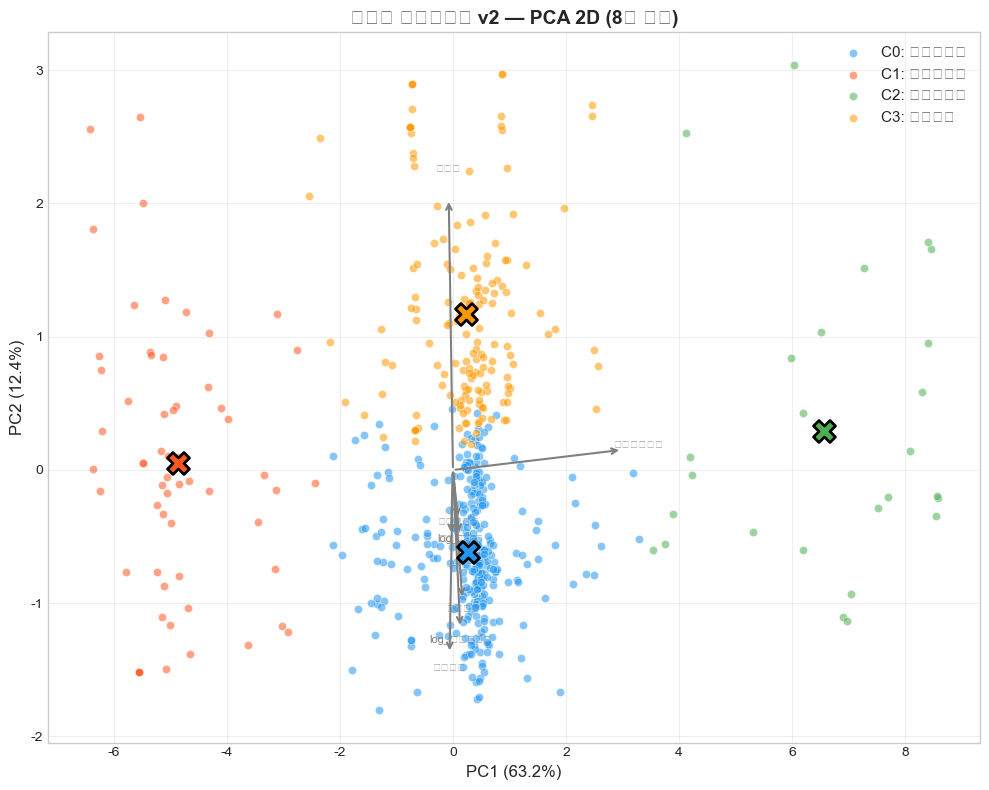

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA 설명 분산: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'누적: {pca.explained_variance_ratio_.sum():.3f}')

# PCA 로딩
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=['PC1', 'PC2'])
print(f'\nPCA 로딩:')
display(loadings.round(3))

# 산점도
fig, ax = plt.subplots(figsize=(10, 8))
for c in sorted(df['cluster_v2'].unique()):
    mask = df['cluster_v2'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[c], label=v2_labels[c],
               alpha=0.55, s=35, edgecolors='white', linewidth=0.5)

# 클러스터 중심
centers_pca = pca.transform(kmeans_v2.cluster_centers_)
for c in sorted(df['cluster_v2'].unique()):
    ax.scatter(centers_pca[c, 0], centers_pca[c, 1],
               c=COLORS[c], marker='X', s=250, edgecolors='black', linewidth=2, zorder=10)

# PCA loading 화살표
scale_factor = 3
for i, feat in enumerate(CLUSTER_FEATURES):
    ax.annotate('', xy=(loadings.iloc[i, 0]*scale_factor, loadings.iloc[i, 1]*scale_factor),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(loadings.iloc[i, 0]*scale_factor*1.1, loadings.iloc[i, 1]*scale_factor*1.1,
            feat, fontsize=8, color='gray', ha='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title('보호소 클러스터링 v2 — PCA 2D (8개 피처)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_v2_pca_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3-8. t-SNE 2D 산점도 (비선형 구조)

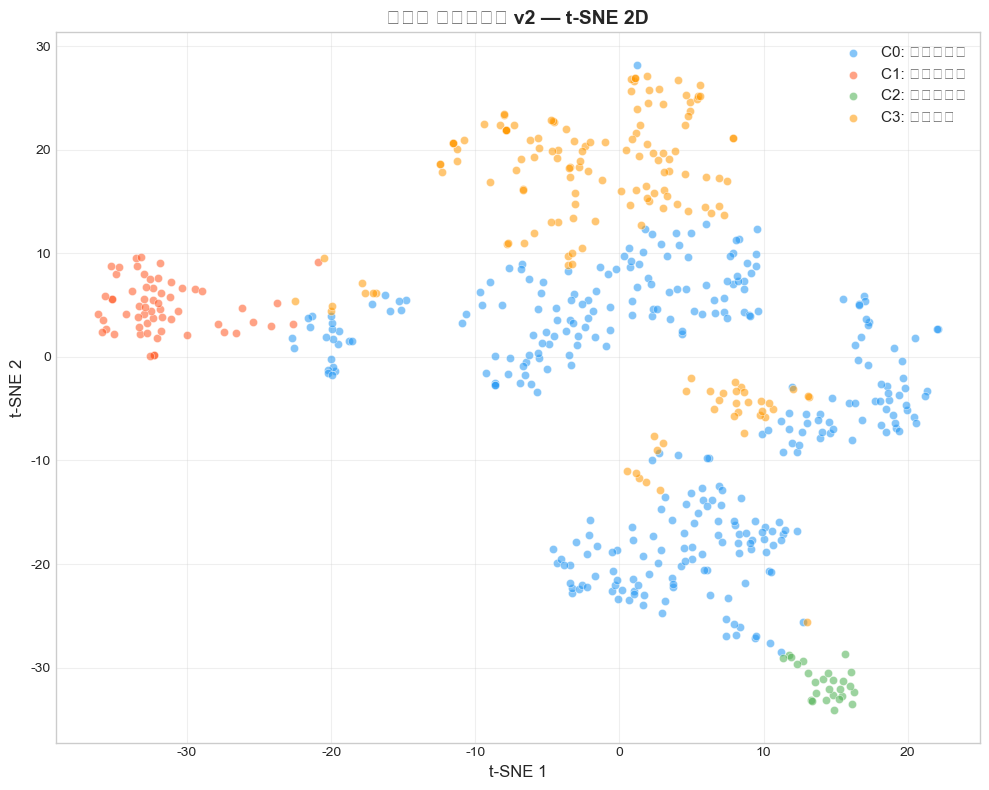

In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for c in sorted(df['cluster_v2'].unique()):
    mask = df['cluster_v2'] == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=COLORS[c], label=v2_labels[c],
               alpha=0.55, s=35, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('보호소 클러스터링 v2 — t-SNE 2D', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_v2_tsne_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3-9. 클러스터별 레이더 차트 (8개 피처 프로파일)

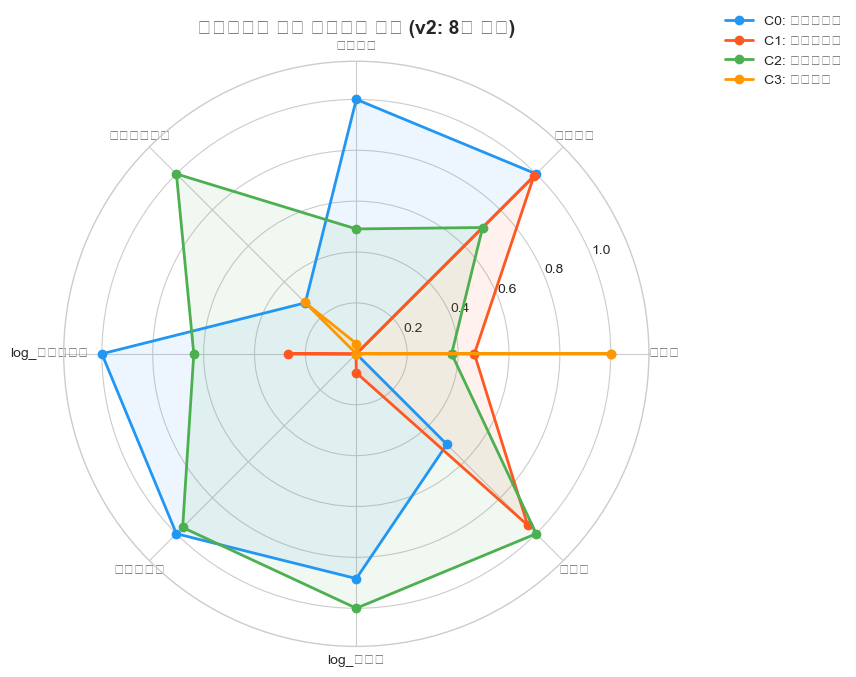

In [12]:
means = df.groupby('cluster_v2')[CLUSTER_FEATURES].mean()
# Min-Max 정규화 (레이더 비교용)
means_norm = (means - means.min()) / (means.max() - means.min())

categories = CLUSTER_FEATURES
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for c in sorted(df['cluster_v2'].unique()):
    values = means_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=v2_labels[c], color=COLORS[c])
    ax.fill(angles, values, alpha=0.08, color=COLORS[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('클러스터별 운영 프로파일 비교 (v2: 8개 피처)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_v2_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3-10. 사회경제 변수 사후 해석

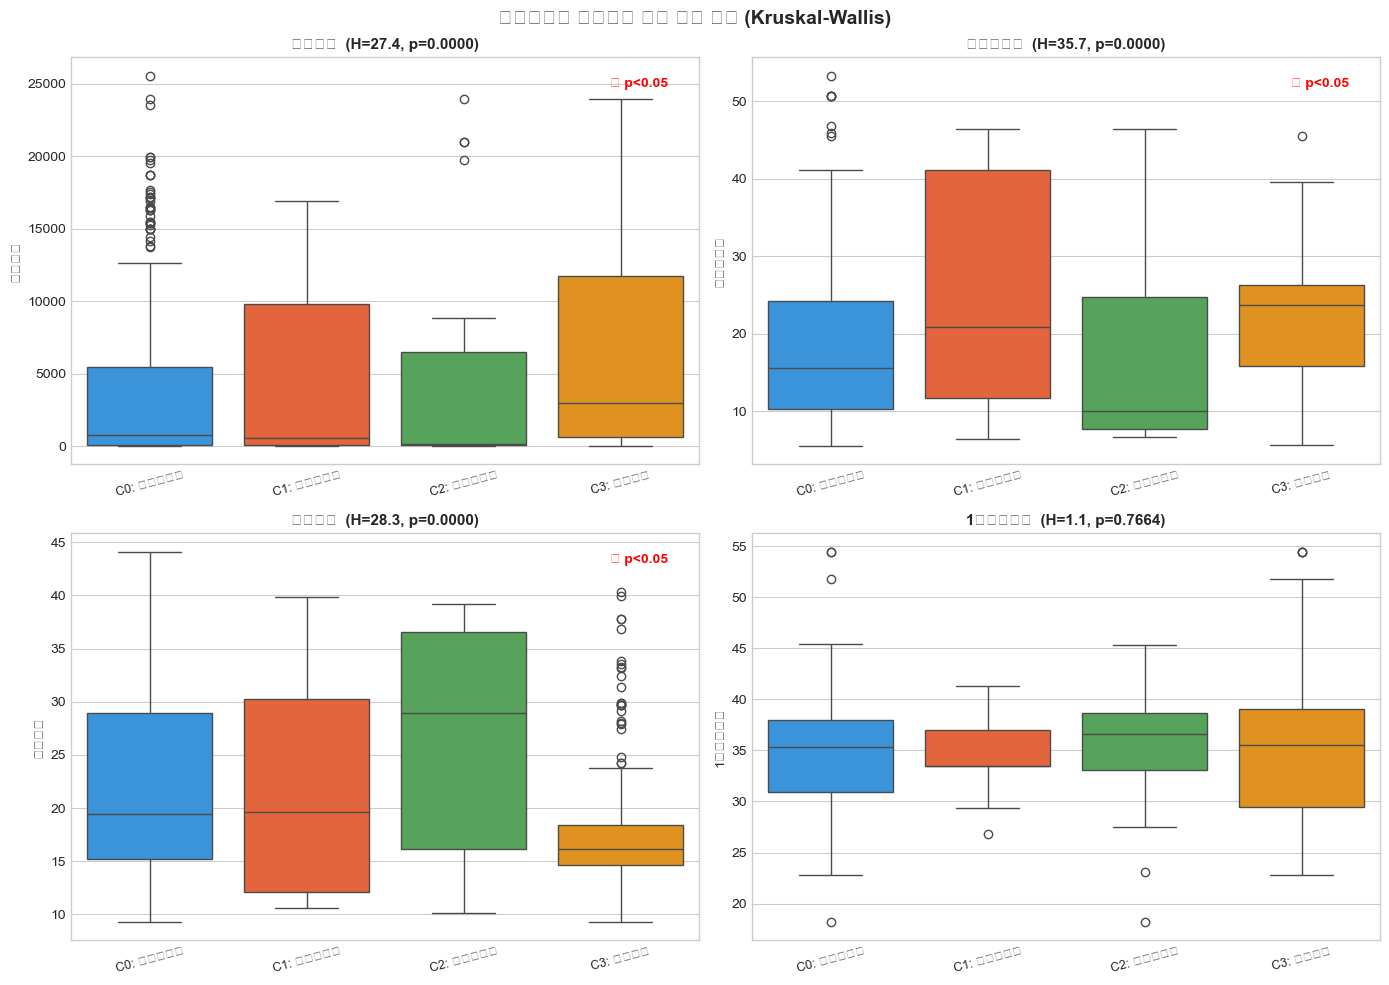

In [13]:
# 사후 해석: 클러스터별 사회경제 변수 boxplot + Kruskal-Wallis 검정
socio_plot_vars = ['인구밀도', '재정자립도', '고령화율', '1인가구비율']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, var in enumerate(socio_plot_vars):
    data_groups = [df[df['cluster_v2'] == c][var].dropna() for c in sorted(df['cluster_v2'].unique())]

    # Kruskal-Wallis 검정
    if all(len(g) > 0 for g in data_groups):
        stat, pval = stats.kruskal(*data_groups)
    else:
        stat, pval = np.nan, np.nan

    sns.boxplot(data=df, x='cluster_v2_label', y=var, ax=axes[i],
                palette=COLORS[:OPTIMAL_K], order=[v2_labels[c] for c in sorted(df['cluster_v2'].unique())])
    axes[i].set_title(f'{var}  (H={stat:.1f}, p={pval:.4f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15, labelsize=9)

    # 유의성 표시
    if pval < 0.05:
        axes[i].text(0.95, 0.95, '★ p<0.05', transform=axes[i].transAxes,
                     ha='right', va='top', fontsize=10, color='red', fontweight='bold')

plt.suptitle('클러스터별 사회경제 변수 사후 비교 (Kruskal-Wallis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_v2_socioeconomic_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3-11. Robustness Check — Track B (인프라 매칭 보호소만, N=333)

In [14]:
# Track B: 인프라정보유무 == 1인 보호소만
df_trackB = df[df['인프라정보유무'] == 1].copy()
print(f'Track B 보호소 수: {len(df_trackB)}')

X_trackB = df_trackB[CLUSTER_FEATURES].copy()
# 동일한 이상치 클리핑
for col in CLUSTER_FEATURES:
    if col in ['수의사유무']:
        continue
    p99 = X_trackB[col].quantile(0.99)
    p01 = X_trackB[col].quantile(0.01)
    X_trackB[col] = X_trackB[col].clip(lower=p01, upper=p99)

scaler_B = RobustScaler()
X_scaled_B = scaler_B.fit_transform(X_trackB)

# 동일 K로 클러스터링
kmeans_B = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
labels_B = kmeans_B.fit_predict(X_scaled_B)
df_trackB['cluster_trackB'] = labels_B

sil_B = silhouette_score(X_scaled_B, labels_B)
print(f'Track B Silhouette Score: {sil_B:.4f}')

# Track A의 인프라 보유 보호소와 Track B의 ARI 비교
df_AB = df[df['인프라정보유무'] == 1][['보호소명', 'cluster_v2']].merge(
    df_trackB[['보호소명', 'cluster_trackB']], on='보호소명'
)
ari_AB = adjusted_rand_score(df_AB['cluster_v2'], df_AB['cluster_trackB'])

print(f'\n=== Track A vs Track B Robustness ===')
print(f'Track A (전체 564개) Silhouette: {silhouette_score(X_scaled, df["cluster_v2"]):.4f}')
print(f'Track B ({len(df_trackB)}개) Silhouette: {sil_B:.4f}')
print(f'ARI (A vs B, 인프라 보유 보호소): {ari_AB:.4f}')
print(f'  → {"안정적 (ARI>0.5)" if ari_AB > 0.5 else "차이 존재 — 인프라 결측 대체 효과 유의"}')

# Track B 클러스터 분포
print(f'\nTrack B 클러스터 분포:')
print(df_trackB['cluster_trackB'].value_counts().sort_index())

Track B 보호소 수: 325
Track B Silhouette Score: 0.4452

=== Track A vs Track B Robustness ===
Track A (전체 564개) Silhouette: 0.2624
Track B (325개) Silhouette: 0.4452
ARI (A vs B, 인프라 보유 보호소): 0.1737
  → 차이 존재 — 인프라 결측 대체 효과 유의

Track B 클러스터 분포:
cluster_trackB
0    247
1     20
2     15
3     43
Name: count, dtype: int64


## 4. 2단계 — 전체 모델 + 클러스터별 입양률 결정요인

### 4-1. 회귀 독립변수 정의

In [15]:
# 회귀 분석에 사용할 피처 확인
print(f'종속변수: {TARGET}')
print(f'독립변수 ({len(REGRESSION_FEATURES)}개): {REGRESSION_FEATURES}')

# 결측 확인
X_reg = df[REGRESSION_FEATURES].copy()
y_reg = df[TARGET].copy()

print(f'\n독립변수 결측:')
reg_missing = X_reg.isnull().sum()
reg_missing = reg_missing[reg_missing > 0]
if len(reg_missing) > 0:
    for col, cnt in reg_missing.items():
        print(f'  {col}: {cnt}개')
    # 잔여 결측 중앙값 대체
    X_reg = X_reg.fillna(X_reg.median())
    print('  → 중앙값 대체 완료')
else:
    print('  없음')

print(f'\n독립변수 기초통계:')
display(X_reg.describe().round(3))

종속변수: 입양률
독립변수 (19개): ['log_총보호건수', '수의사유무', 'log_총인력', '개비율', '반환률', '인력밀도', '인프라정보유무', '안락사율', '자연사율', '평균보호기간', '인구밀도', '재정자립도', '고령화율', '1인가구비율', '센터유형_개인', '센터유형_단체', '센터유형_동물병원', '센터유형_미상', '센터유형_법인']

독립변수 결측:
  없음

독립변수 기초통계:


,log_총보호건수,수의사유무,log_총인력,개비율,반환률,인력밀도,인프라정보유무,안락사율,자연사율,평균보호기간,인구밀도,재정자립도,고령화율,1인가구비율
count,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000,564.000
mean,5.637,0.450,0.862,66.106,13.540,1.570,0.576,18.875,23.826,10.537,4657.531,19.575,21.177,34.658
std,2.451,0.498,0.864,31.495,16.014,2.549,0.495,21.717,19.979,4.765,6112.303,10.044,8.523,5.466
min,0.693,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,16.614,5.492,9.288,18.198
25%,3.984,0.000,0.000,43.180,3.624,0.000,0.000,0.388,7.890,10.052,136.080,11.078,15.060,30.555
50%,6.491,0.000,1.099,74.299,9.148,0.751,1.000,12.510,21.380,10.551,1112.383,17.327,17.557,35.187
75%,7.542,1.000,1.609,94.341,18.195,2.000,1.000,29.595,34.295,10.673,8839.608,25.058,27.478,38.076
max,10.454,1.000,3.367,100.000,100.000,28.000,1.000,100.000,100.000,116.832,25537.067,53.303,44.090,54.450


### 4-2. 전체 모델 (Global, N=564): LightGBM 회귀, 5-Fold CV

In [16]:
# LightGBM 하이퍼파라미터
lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1
}

# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_global = lgb.LGBMRegressor(**lgb_params)

y_pred_cv = cross_val_predict(model_global, X_reg, y_reg, cv=kf)

mae_global = mean_absolute_error(y_reg, y_pred_cv)
r2_global = r2_score(y_reg, y_pred_cv)

print(f'=== 전체 모델 (Global) 5-Fold CV ===')
print(f'MAE : {mae_global:.2f}')
print(f'R²  : {r2_global:.4f}')

# Fold별 성능
print(f'\nFold별 성능:')
for i, (train_idx, val_idx) in enumerate(kf.split(X_reg)):
    y_val = y_reg.iloc[val_idx]
    y_pred_fold = y_pred_cv[val_idx]
    mae_f = mean_absolute_error(y_val, y_pred_fold)
    r2_f = r2_score(y_val, y_pred_fold)
    print(f'  Fold {i+1}: MAE={mae_f:.2f}, R²={r2_f:.4f}')

# 전체 데이터로 재학습 (SHAP용)
model_global.fit(X_reg, y_reg)

# 모델 저장
with open(os.path.join(MODEL_DIR, 'lgbm_regression_global.pkl'), 'wb') as f:
    pickle.dump(model_global, f)
print(f'\n모델 저장: {os.path.join(MODEL_DIR, "lgbm_regression_global.pkl")}')

=== 전체 모델 (Global) 5-Fold CV ===
MAE : 9.32
R²  : 0.5640

Fold별 성능:
  Fold 1: MAE=8.61, R²=0.6030
  Fold 2: MAE=11.04, R²=0.4507
  Fold 3: MAE=8.38, R²=0.5961
  Fold 4: MAE=9.82, R²=0.4383
  Fold 5: MAE=8.76, R²=0.6958



모델 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/06_models/lgbm_regression_global.pkl


### 4-3. 전체 모델 SHAP 분석

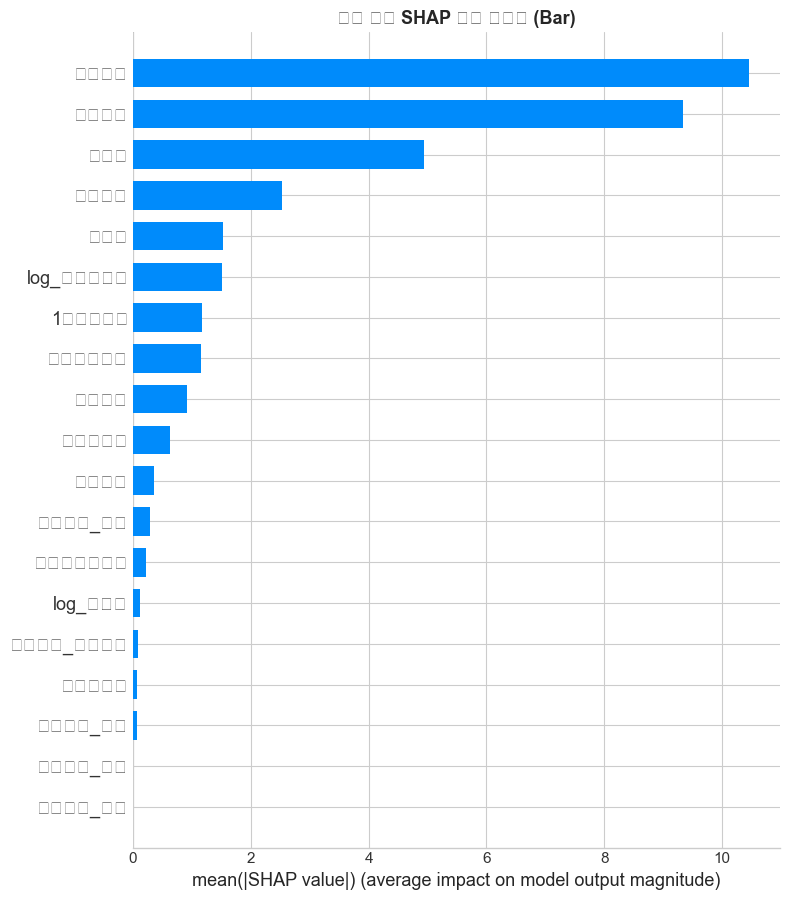

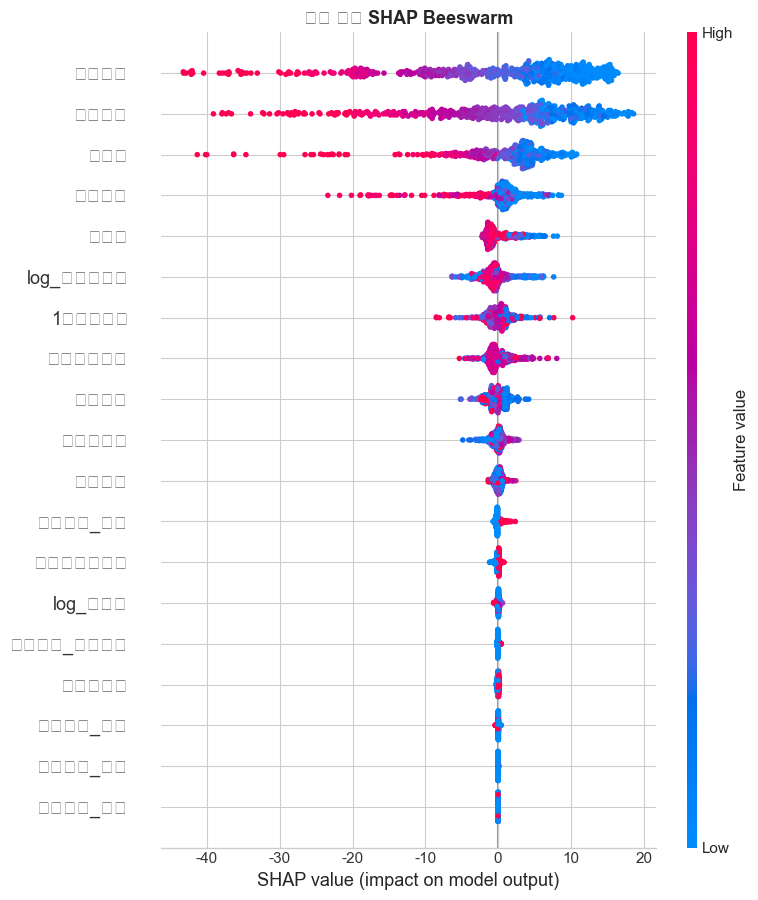


=== 전체 모델 SHAP Top 10 ===


,변수,mean_abs_shap
0,안락사율,10.462843
1,자연사율,9.343734
2,반환률,4.947280
3,인구밀도,2.527227
4,개비율,1.523056
5,log_총보호건수,1.508680
6,1인가구비율,1.176925
7,평균보호기간,1.155426
8,고령화율,0.918404
9,재정자립도,0.635988


In [17]:
# SHAP TreeExplainer
explainer_global = shap.TreeExplainer(model_global)
shap_values_global = explainer_global.shap_values(X_reg)

# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_global, X_reg, plot_type='bar',
                  show=False, max_display=len(REGRESSION_FEATURES))
plt.title('전체 모델 SHAP 변수 중요도 (Bar)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

# SHAP Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values_global, X_reg, show=False,
                  max_display=len(REGRESSION_FEATURES))
plt.title('전체 모델 SHAP Beeswarm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

# SHAP 변수 중요도 저장
shap_importance_global = pd.DataFrame({
    '변수': REGRESSION_FEATURES,
    'mean_abs_shap': np.abs(shap_values_global).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
print('\n=== 전체 모델 SHAP Top 10 ===')
display(shap_importance_global.head(10).reset_index(drop=True))

### 4-4. 클러스터별 모델 학습 함수 정의

In [18]:
def train_cluster_model(df_sub, features, target, cluster_id, model_dir):
    """클러스터별 LightGBM 회귀 모델 학습 + SHAP 분석

    N < 40: 기술통계만 반환
    N < 100: 3-Fold CV, max_depth=4, num_leaves=15
    N >= 100: 5-Fold CV
    """
    N = len(df_sub)
    X = df_sub[features].copy().fillna(df_sub[features].median())
    y = df_sub[target].copy()

    result = {
        'cluster': cluster_id,
        'N': N,
        'mae': np.nan,
        'r2': np.nan,
        'model': None,
        'shap_values': None,
        'X': X,
        'y': y,
        'status': ''
    }

    if N < 40:
        result['status'] = f'소표본 (N={N}) — 기술통계만'
        print(f'  클러스터 {cluster_id}: N={N} < 40 → 기술통계만 수행')
        return result

    # 하이퍼파라미터 (표본 크기에 따라 조정)
    params = lgb_params.copy()
    if N < 100:
        params['max_depth'] = 4
        params['num_leaves'] = 15
        params['n_estimators'] = 200
        n_folds = 3
    else:
        n_folds = 5

    model = lgb.LGBMRegressor(**params)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    y_pred = cross_val_predict(model, X, y, cv=kf)
    result['mae'] = mean_absolute_error(y, y_pred)
    result['r2'] = r2_score(y, y_pred)
    result['status'] = f'{n_folds}-Fold CV'

    # 전체 데이터로 재학습 (SHAP용)
    model.fit(X, y)
    result['model'] = model

    # SHAP
    explainer = shap.TreeExplainer(model)
    result['shap_values'] = explainer.shap_values(X)

    # 모델 저장
    pkl_path = os.path.join(model_dir, f'lgbm_regression_cluster{cluster_id}.pkl')
    with open(pkl_path, 'wb') as f:
        pickle.dump(model, f)

    print(f'  클러스터 {cluster_id}: N={N}, {n_folds}-Fold MAE={result["mae"]:.2f}, R²={result["r2"]:.4f}')
    return result

print('클러스터별 모델 학습 함수 정의 완료')

클러스터별 모델 학습 함수 정의 완료


### 4-5. 클러스터별 모델 실행 및 성능 비교

In [19]:
print('=== 클러스터별 모델 학습 ===')
cluster_results = {}

for c in sorted(df['cluster_v2'].unique()):
    df_sub = df[df['cluster_v2'] == c]
    result = train_cluster_model(df_sub, REGRESSION_FEATURES, TARGET, c, MODEL_DIR)
    cluster_results[c] = result

# 성능 비교 테이블
perf_rows = [{'클러스터': v2_labels.get(r['cluster'], f'C{r["cluster"]}'),
              'N': r['N'],
              'MAE': f"{r['mae']:.2f}" if not np.isnan(r['mae']) else '-',
              'R²': f"{r['r2']:.4f}" if not np.isnan(r['r2']) else '-',
              'CV': r['status']}
             for r in cluster_results.values()]
# 전체 모델 추가
perf_rows.insert(0, {'클러스터': '전체 (Global)', 'N': len(df),
                      'MAE': f'{mae_global:.2f}', 'R²': f'{r2_global:.4f}', 'CV': '5-Fold'})

perf_df = pd.DataFrame(perf_rows)
print('\n=== 성능 비교 ===')
display(perf_df)

=== 클러스터별 모델 학습 ===


  클러스터 0: N=319, 5-Fold MAE=5.14, R²=0.6807


  클러스터 1: N=60, 3-Fold MAE=17.53, R²=0.1599
  클러스터 2: N=26 < 40 → 기술통계만 수행


  클러스터 3: N=159, 5-Fold MAE=15.97, R²=0.2396

=== 성능 비교 ===


,클러스터,N,MAE,R²,CV
0,전체 (Global),564,9.32,0.5640,5-Fold
1,C0: 고안락사형,319,5.14,0.6807,5-Fold CV
2,C1: 균형관리형,60,17.53,0.1599,3-Fold CV
3,C2: 균형관리형,26,-,-,소표본 (N=26) — 기술통계만
4,C3: 고입양형,159,15.97,0.2396,5-Fold CV


### 4-6. 클러스터별 SHAP Bar (2×2 Grid)

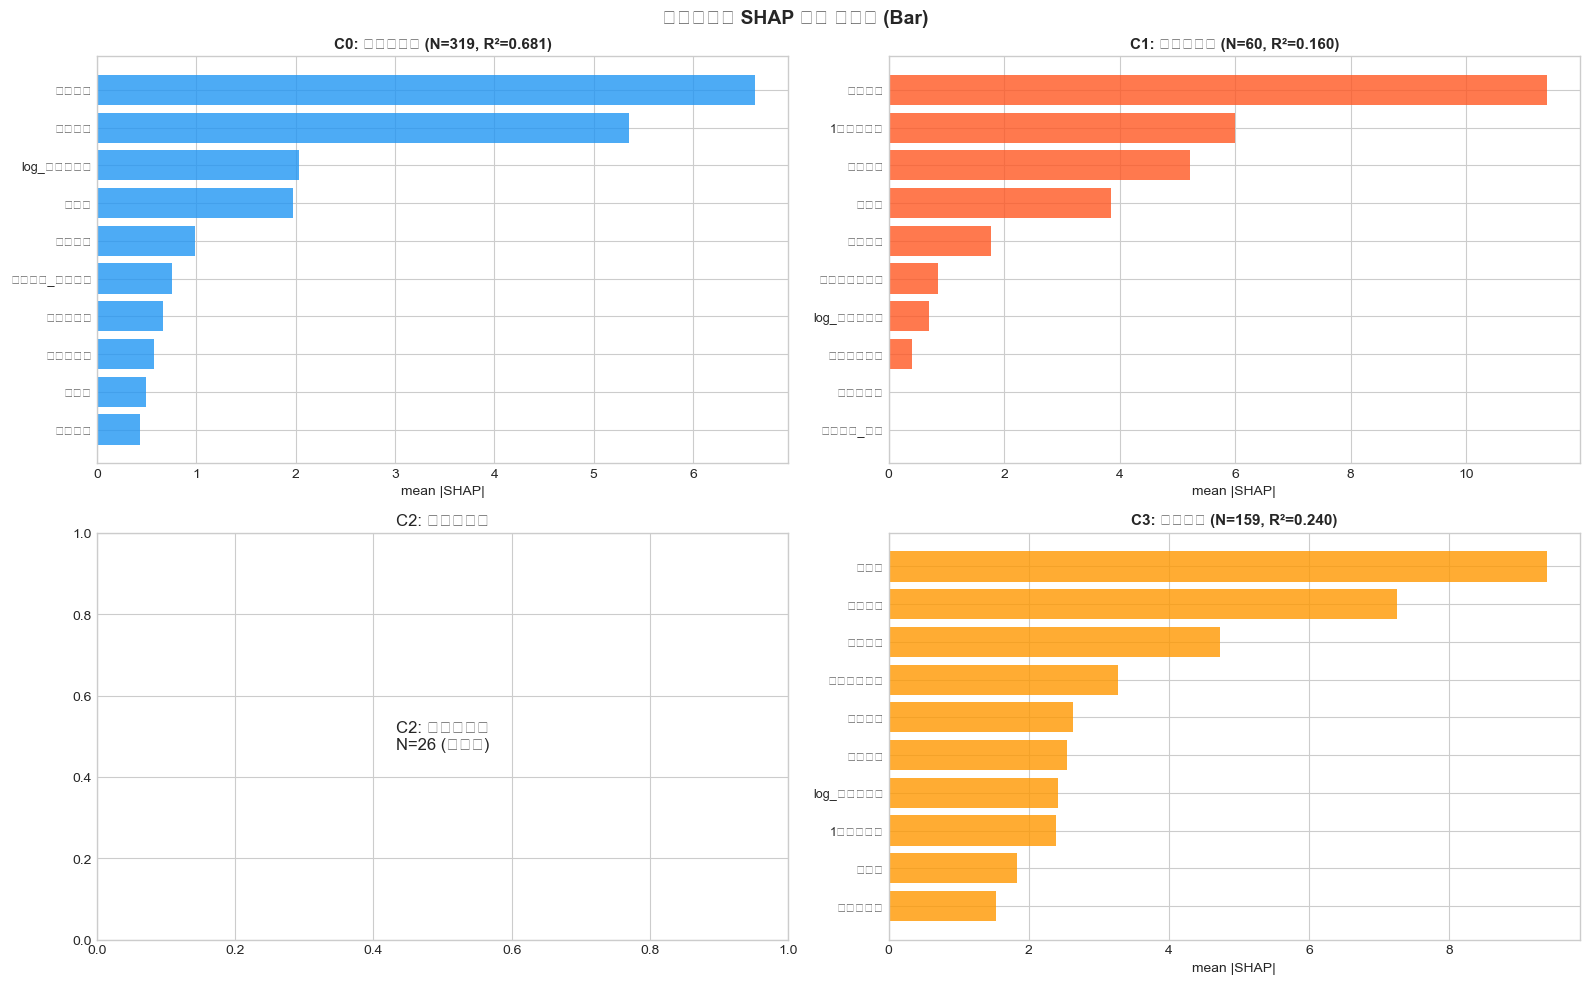

In [20]:
n_clusters = OPTIMAL_K
n_rows = (n_clusters + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.ravel()

for i, c in enumerate(sorted(cluster_results.keys())):
    r = cluster_results[c]
    if r['shap_values'] is None:
        axes[i].text(0.5, 0.5, f'{v2_labels[c]}\nN={r["N"]} (소표본)',
                     ha='center', va='center', fontsize=12, transform=axes[i].transAxes)
        axes[i].set_title(v2_labels[c])
        continue

    # SHAP bar
    mean_shap = np.abs(r['shap_values']).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1]
    top_n = min(10, len(REGRESSION_FEATURES))

    axes[i].barh(range(top_n), mean_shap[sorted_idx[:top_n]][::-1],
                 color=COLORS[c], alpha=0.8)
    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels([REGRESSION_FEATURES[j] for j in sorted_idx[:top_n]][::-1], fontsize=9)
    axes[i].set_title(f'{v2_labels[c]} (N={r["N"]}, R²={r["r2"]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('mean |SHAP|')

# 빈 축 제거
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('클러스터별 SHAP 변수 중요도 (Bar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_shap_bar_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4-7. 클러스터별 SHAP Beeswarm (2×2 Grid)

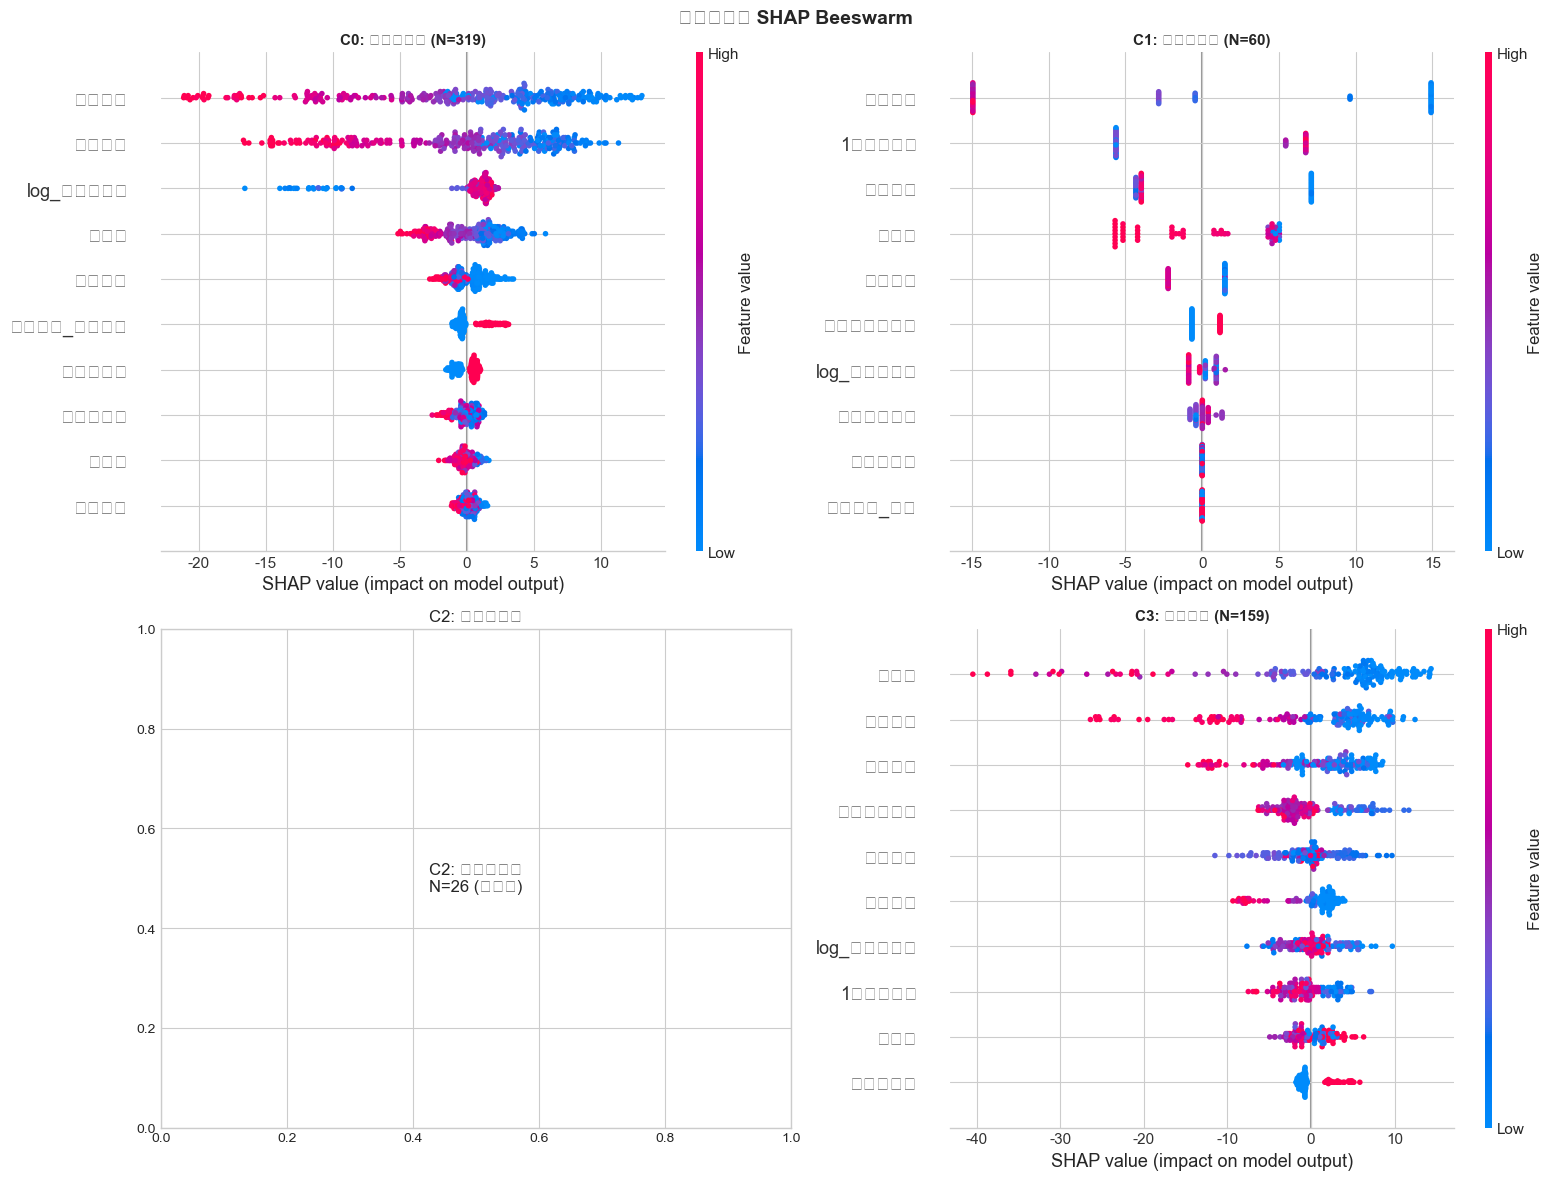

In [21]:
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 6*n_rows))
axes = axes.ravel()

for i, c in enumerate(sorted(cluster_results.keys())):
    r = cluster_results[c]
    if r['shap_values'] is None:
        axes[i].text(0.5, 0.5, f'{v2_labels[c]}\nN={r["N"]} (소표본)',
                     ha='center', va='center', fontsize=12, transform=axes[i].transAxes)
        axes[i].set_title(v2_labels[c])
        continue

    plt.sca(axes[i])
    shap.summary_plot(r['shap_values'], r['X'], show=False,
                      max_display=10, plot_size=None)
    axes[i].set_title(f'{v2_labels[c]} (N={r["N"]})', fontsize=11, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('클러스터별 SHAP Beeswarm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_shap_beeswarm_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. 클러스터 간 SHAP 비교 — 핵심 산출물

### 5-1. SHAP 변수 중요도 비교 히트맵

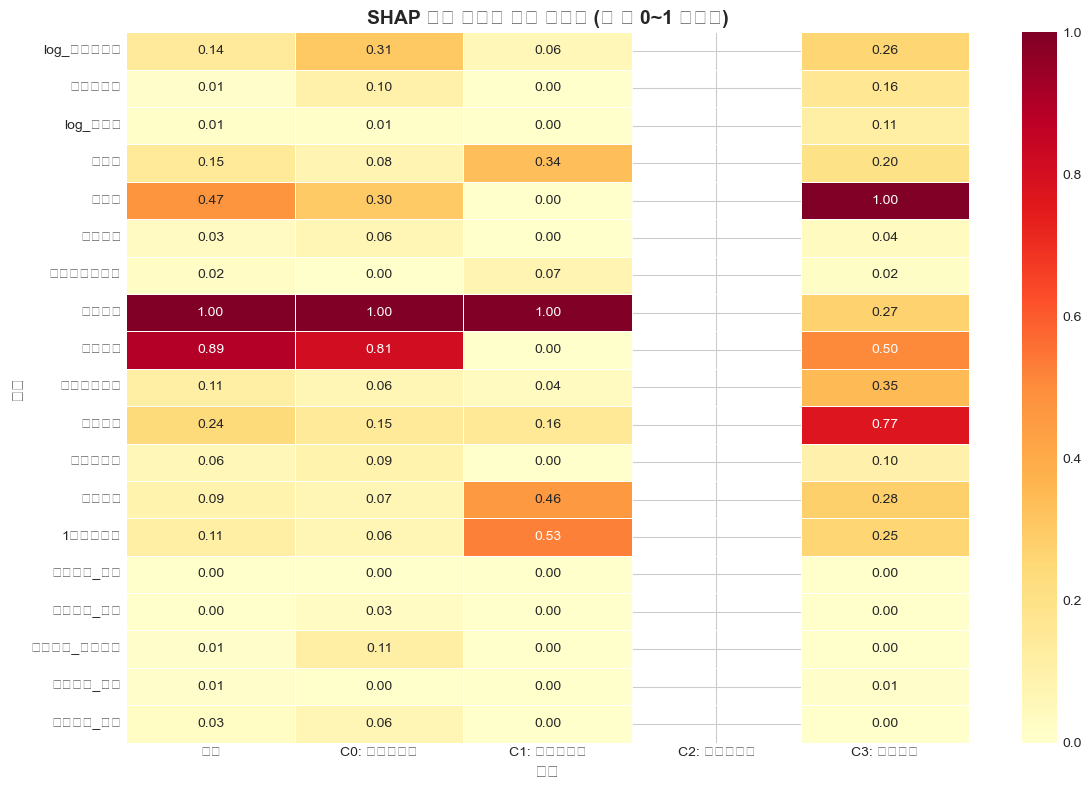

저장: cluster_v2_shap_importance.csv


In [22]:
# SHAP 중요도 행렬 (행=변수, 열=클러스터)
shap_matrix = pd.DataFrame(index=REGRESSION_FEATURES)

# 전체 모델
shap_matrix['전체'] = np.abs(shap_values_global).mean(axis=0)

# 클러스터별
for c in sorted(cluster_results.keys()):
    r = cluster_results[c]
    if r['shap_values'] is not None:
        shap_matrix[v2_labels[c]] = np.abs(r['shap_values']).mean(axis=0)
    else:
        shap_matrix[v2_labels[c]] = np.nan

# 열 내 0~1 정규화 (상대 중요도 비교)
shap_norm = shap_matrix.copy()
for col in shap_norm.columns:
    col_max = shap_norm[col].max()
    if col_max > 0:
        shap_norm[col] = shap_norm[col] / col_max

# 히트맵
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(shap_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('SHAP 변수 중요도 비교 히트맵 (열 내 0~1 정규화)', fontsize=14, fontweight='bold')
ax.set_xlabel('모델', fontsize=12)
ax.set_ylabel('변수', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cross_cluster_shap_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# CSV 저장
shap_matrix.to_csv(os.path.join(DATA_DIR, 'cluster_v2_shap_importance.csv'),
                   encoding='utf-8-sig')
print(f'저장: cluster_v2_shap_importance.csv')

### 5-2. SHAP 순위 변동 Bump Chart

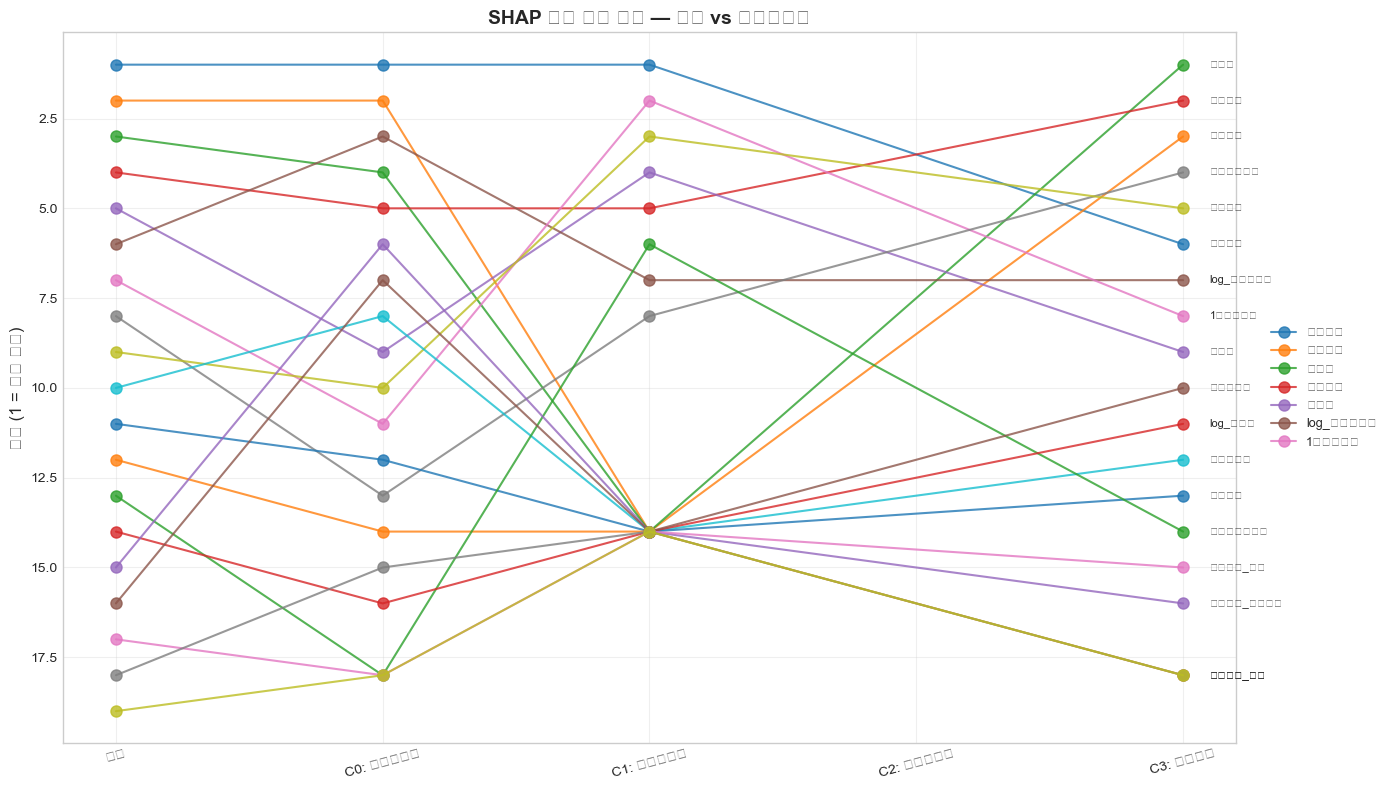

In [23]:
# 각 열의 순위 계산 (1 = 가장 중요)
rank_matrix = shap_matrix.rank(ascending=False)
# NaN이 있으면 int 변환 불가하므로 float 유지
rank_matrix = rank_matrix.where(rank_matrix.notna(), np.nan)

# 변수별로 전체 모델 순위 기준 정렬
rank_matrix = rank_matrix.sort_values('전체')

# Bump Chart
fig, ax = plt.subplots(figsize=(14, 8))
x_positions = list(range(len(rank_matrix.columns)))
x_labels = list(rank_matrix.columns)

for feat in rank_matrix.index:
    ranks = rank_matrix.loc[feat].values.astype(float)
    valid = ~np.isnan(ranks)
    if valid.sum() < 2:
        continue
    ax.plot(np.array(x_positions)[valid], ranks[valid], 'o-', linewidth=1.5,
            markersize=8, label=feat, alpha=0.8)
    last_valid_idx = np.where(valid)[0][-1]
    ax.text(last_valid_idx + 0.1, ranks[last_valid_idx], feat,
            fontsize=8, va='center')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=10, rotation=15)
ax.set_ylabel('순위 (1 = 가장 중요)', fontsize=12)
ax.set_title('SHAP 변수 순위 변동 — 전체 vs 클러스터별', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# 범례 (상위 7개 변수만)
top_vars = rank_matrix.sort_values('전체').index[:7].tolist()
handles = [line for line in ax.get_lines() if line.get_label() in top_vars]
if handles:
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cross_cluster_shap_rank_bump.png'), dpi=150, bbox_inches='tight')
plt.show()


### 5-3. 차별적 요인 자동 추출

In [24]:
# 전체 모델 대비 순위 변동이 큰 변수 식별
print('=== 차별적 요인 (전체 모델 대비 순위 변동 >= 3) ===\n')

differential_factors = []

for col in rank_matrix.columns:
    if col == '전체':
        continue
    for feat in rank_matrix.index:
        r_global = rank_matrix.loc[feat, '전체']
        r_cluster = rank_matrix.loc[feat, col]
        if np.isnan(r_global) or np.isnan(r_cluster):
            continue
        d = r_cluster - r_global
        if abs(d) >= 3:
            direction = '↑ 상승' if d < 0 else '↓ 하락'
            differential_factors.append({
                '클러스터': col,
                '변수': feat,
                '전체순위': int(r_global),
                '클러스터순위': int(r_cluster),
                '변동': int(d),
                '방향': direction
            })
            print(f'  {col} | {feat}: 전체 {int(r_global)}위 → '
                  f'{col} {int(r_cluster)}위 ({direction}, Δ={abs(int(d))})')

if not differential_factors:
    print('  순위 변동 >= 3인 변수 없음 (클러스터 간 패턴이 유사)')

diff_df = pd.DataFrame(differential_factors)
if len(diff_df) > 0:
    print(f'\n총 {len(diff_df)}개 차별적 요인 발견')
    display(diff_df.sort_values('변동', key=abs, ascending=False))


=== 차별적 요인 (전체 모델 대비 순위 변동 >= 3) ===

  C0: 고안락사형 | 개비율: 전체 5위 → C0: 고안락사형 9위 (↓ 하락, Δ=4)
  C0: 고안락사형 | log_총보호건수: 전체 6위 → C0: 고안락사형 3위 (↑ 상승, Δ=3)
  C0: 고안락사형 | 1인가구비율: 전체 7위 → C0: 고안락사형 11위 (↓ 하락, Δ=4)
  C0: 고안락사형 | 평균보호기간: 전체 8위 → C0: 고안락사형 13위 (↓ 하락, Δ=5)
  C0: 고안락사형 | 인프라정보유무: 전체 13위 → C0: 고안락사형 18위 (↓ 하락, Δ=5)
  C0: 고안락사형 | 센터유형_동물병원: 전체 15위 → C0: 고안락사형 6위 (↑ 상승, Δ=9)
  C0: 고안락사형 | 수의사유무: 전체 16위 → C0: 고안락사형 7위 (↑ 상승, Δ=9)
  C0: 고안락사형 | 센터유형_단체: 전체 18위 → C0: 고안락사형 15위 (↑ 상승, Δ=3)
  C1: 균형관리형 | 자연사율: 전체 2위 → C1: 균형관리형 14위 (↓ 하락, Δ=12)
  C1: 균형관리형 | 반환률: 전체 3위 → C1: 균형관리형 14위 (↓ 하락, Δ=11)
  C1: 균형관리형 | 1인가구비율: 전체 7위 → C1: 균형관리형 2위 (↑ 상승, Δ=5)
  C1: 균형관리형 | 고령화율: 전체 9위 → C1: 균형관리형 3위 (↑ 상승, Δ=6)
  C1: 균형관리형 | 재정자립도: 전체 10위 → C1: 균형관리형 14위 (↓ 하락, Δ=4)
  C1: 균형관리형 | 인력밀도: 전체 11위 → C1: 균형관리형 14위 (↓ 하락, Δ=3)
  C1: 균형관리형 | 인프라정보유무: 전체 13위 → C1: 균형관리형 6위 (↑ 상승, Δ=7)
  C1: 균형관리형 | 센터유형_미상: 전체 17위 → C1: 균형관리형 14위 (↑ 상승, Δ=3)
  C1: 균형관리형 | 센터유형_단체: 전체 18위 → C1: 균형관리형 14위 (↑ 상승, Δ=4)
  C1: 균형관

,클러스터,변수,전체순위,클러스터순위,변동,방향
8,C1: 균형관리형,자연사율,2,14,12,↓ 하락
9,C1: 균형관리형,반환률,3,14,11,↓ 하락
5,C0: 고안락사형,센터유형_동물병원,15,6,-9,↑ 상승
6,C0: 고안락사형,수의사유무,16,7,-9,↑ 상승
14,C1: 균형관리형,인프라정보유무,13,6,-7,↑ 상승
24,C3: 고입양형,수의사유무,16,10,-6,↑ 상승
22,C3: 고입양형,센터유형_법인,12,18,6,↓ 하락
11,C1: 균형관리형,고령화율,9,3,-6,↑ 상승
17,C1: 균형관리형,센터유형_개인,19,14,-5,↑ 상승
3,C0: 고안락사형,평균보호기간,8,13,5,↓ 하락


### 5-4. 전체 vs 클러스터별 SHAP Top 5 비교 요약

In [25]:
# Top 5 비교 테이블
top5_comparison = {}

# 전체 모델 Top 5
global_top5 = shap_importance_global.head(5)['변수'].tolist()
top5_comparison['전체'] = global_top5

# 클러스터별 Top 5
for c in sorted(cluster_results.keys()):
    r = cluster_results[c]
    if r['shap_values'] is not None:
        mean_shap = np.abs(r['shap_values']).mean(axis=0)
        sorted_idx = np.argsort(mean_shap)[::-1][:5]
        top5 = [REGRESSION_FEATURES[i] for i in sorted_idx]
        top5_comparison[v2_labels[c]] = top5
    else:
        top5_comparison[v2_labels[c]] = ['(소표본)'] * 5

# 테이블 출력
top5_df = pd.DataFrame(top5_comparison, index=[f'Top {i+1}' for i in range(5)])
print('=== SHAP Top 5 변수 비교 ===')
display(top5_df)

# 전체 모델에서는 중요하지 않았으나 특정 클러스터에서 중요한 변수
print('\n=== 핵심 인사이트 ===')
for c in sorted(cluster_results.keys()):
    label = v2_labels[c]
    if label not in top5_comparison:
        continue
    cluster_top5 = set(top5_comparison[label])
    global_top5_set = set(global_top5)
    unique_to_cluster = cluster_top5 - global_top5_set - {'(소표본)'}
    if unique_to_cluster:
        print(f'  {label}: 전체 모델과 다른 Top5 변수 → {unique_to_cluster}')

=== SHAP Top 5 변수 비교 ===


,전체,C0: 고안락사형,C1: 균형관리형,C2: 균형관리형,C3: 고입양형
Top 1,안락사율,안락사율,안락사율,(소표본),반환률
Top 2,자연사율,자연사율,1인가구비율,(소표본),인구밀도
Top 3,반환률,log_총보호건수,고령화율,(소표본),자연사율
Top 4,인구밀도,반환률,개비율,(소표본),평균보호기간
Top 5,개비율,인구밀도,인구밀도,(소표본),고령화율



=== 핵심 인사이트 ===
  C0: 고안락사형: 전체 모델과 다른 Top5 변수 → {'log_총보호건수'}
  C1: 균형관리형: 전체 모델과 다른 Top5 변수 → {'1인가구비율', '고령화율'}
  C3: 고입양형: 전체 모델과 다른 Top5 변수 → {'평균보호기간', '고령화율'}


## 6. 정책 제언

### 6-1. SHAP 기반 자동 정책 매핑

In [26]:
# 변수 → 정책 제언 매핑 딕셔너리
POLICY_MAP = {
    '안락사율': '안락사 대안 프로토콜 도입 (TNR, 협력 입양 네트워크)',
    '자연사율': '의료 인프라 확충 (수의사 상주, 응급의료 시스템)',
    '평균보호기간': '보호기간 최적화 (입양 홍보 강화, 임시보호 프로그램)',
    'log_총보호건수': '보호소 규모별 맞춤 자원 배분',
    '수의사유무': '수의사 배치 의무화/지원 확대',
    'log_총인력': '인력 증원 및 전문인력 양성',
    '개비율': '동물 종별 입양 프로그램 차별화 (고양이 전문 입양센터 등)',
    '반환률': '입양 후 관리 프로그램 강화 (사후 추적, 상담)',
    '인력밀도': '보호소당 적정 인력 기준 마련',
    '인프라정보유무': '보호소 정보 공개 및 표준화 (투명성 제고)',
    '인구밀도': '도시/농촌 특성 고려한 차별화 정책',
    '재정자립도': '지자체 재정 지원 매칭 (교부금 연계)',
    '고령화율': '고령 지역 특화 입양 프로그램 (반려동물 복지 연계)',
    '1인가구비율': '1인 가구 대상 입양 지원 (소형견/고양이 중심)',
}

# 센터유형 관련 매핑
for col in ohe_cols:
    POLICY_MAP[col] = '보호소 운영 방식별 성과 관리 체계 구축'

print('=== 변수 → 정책 매핑 딕셔너리 ===')
for var, policy in POLICY_MAP.items():
    if var in REGRESSION_FEATURES:
        print(f'  {var} → {policy}')

=== 변수 → 정책 매핑 딕셔너리 ===
  안락사율 → 안락사 대안 프로토콜 도입 (TNR, 협력 입양 네트워크)
  자연사율 → 의료 인프라 확충 (수의사 상주, 응급의료 시스템)
  평균보호기간 → 보호기간 최적화 (입양 홍보 강화, 임시보호 프로그램)
  log_총보호건수 → 보호소 규모별 맞춤 자원 배분
  수의사유무 → 수의사 배치 의무화/지원 확대
  log_총인력 → 인력 증원 및 전문인력 양성
  개비율 → 동물 종별 입양 프로그램 차별화 (고양이 전문 입양센터 등)
  반환률 → 입양 후 관리 프로그램 강화 (사후 추적, 상담)
  인력밀도 → 보호소당 적정 인력 기준 마련
  인프라정보유무 → 보호소 정보 공개 및 표준화 (투명성 제고)
  인구밀도 → 도시/농촌 특성 고려한 차별화 정책
  재정자립도 → 지자체 재정 지원 매칭 (교부금 연계)
  고령화율 → 고령 지역 특화 입양 프로그램 (반려동물 복지 연계)
  1인가구비율 → 1인 가구 대상 입양 지원 (소형견/고양이 중심)
  센터유형_개인 → 보호소 운영 방식별 성과 관리 체계 구축
  센터유형_단체 → 보호소 운영 방식별 성과 관리 체계 구축
  센터유형_동물병원 → 보호소 운영 방식별 성과 관리 체계 구축
  센터유형_미상 → 보호소 운영 방식별 성과 관리 체계 구축
  센터유형_법인 → 보호소 운영 방식별 성과 관리 체계 구축


### 6-2. 종합 정책 매트릭스

In [27]:
# 클러스터별 핵심 결정요인 + 정책 제언
policy_rows = []
for c in sorted(cluster_results.keys()):
    r = cluster_results[c]
    label = v2_labels[c]
    n = r['N']
    mean_adoption = df[df['cluster_v2'] == c]['입양률'].mean()

    # 핵심 결정요인 (SHAP Top 3)
    if r['shap_values'] is not None:
        mean_shap = np.abs(r['shap_values']).mean(axis=0)
        top3_idx = np.argsort(mean_shap)[::-1][:3]
        top3_vars = [REGRESSION_FEATURES[i] for i in top3_idx]
    else:
        top3_vars = ['(소표본)']

    # 정책 제언
    policies = [POLICY_MAP.get(v, '') for v in top3_vars if v in POLICY_MAP]

    # 우선순위 = 보호소수 × (1 - 입양률/100)
    priority = n * (1 - mean_adoption / 100)

    policy_rows.append({
        '클러스터': label,
        '보호소수': n,
        '평균입양률': f'{mean_adoption:.1f}%',
        '핵심결정요인': ', '.join(top3_vars),
        '정책제언': ' / '.join(policies[:2]),  # 상위 2개만
        '우선순위점수': f'{priority:.1f}'
    })

policy_matrix = pd.DataFrame(policy_rows)
policy_matrix = policy_matrix.sort_values('우선순위점수', ascending=False)

print('=== 종합 정책 매트릭스 (우선순위 내림차순) ===')
display(policy_matrix)

# CSV 저장
policy_matrix.to_csv(os.path.join(DATA_DIR, 'cluster_v2_policy_recommendations.csv'),
                     index=False, encoding='utf-8-sig')
print(f'\n저장: cluster_v2_policy_recommendations.csv')

=== 종합 정책 매트릭스 (우선순위 내림차순) ===


,클러스터,보호소수,평균입양률,핵심결정요인,정책제언,우선순위점수
3,C3: 고입양형,159,57.4%,"반환률, 인구밀도, 자연사율","입양 후 관리 프로그램 강화 (사후 추적, 상담) / 도시/농촌 특성 고려한 차별화 정책",67.8
1,C1: 균형관리형,60,40.6%,"안락사율, 1인가구비율, 고령화율","안락사 대안 프로토콜 도입 (TNR, 협력 입양 네트워크) / 1인 가구 대상 입양...",35.6
0,C0: 고안락사형,319,26.1%,"안락사율, 자연사율, log_총보호건수","안락사 대안 프로토콜 도입 (TNR, 협력 입양 네트워크) / 의료 인프라 확충 (...",235.7
2,C2: 균형관리형,26,37.8%,(소표본),,16.2



저장: cluster_v2_policy_recommendations.csv


### 6-3. 핵심 발견 정리

#### v2 분석의 차별적 기여

1. **"Where가 아닌 How"의 근거 심화:**
   - v1은 성과 변수(입양률, 안락사율 등)로만 유형화 → "결과 기반 분류"
   - v2는 운영/인프라 변수를 추가하여 "원인 기반 분류"로 진화
   - 같은 클러스터 내에서도 **입양률 결정요인이 상이**함을 SHAP으로 입증

2. **전체 모델에서 잡히지 않는 차별적 패턴:**
   - 전체 모델: 평균적인 변수 중요도만 포착
   - 클러스터별 모델: **유형별 맞춤 전략**의 근거 제공
   - 예) 고안락사형 보호소에서는 X 변수가, 고자연사형에서는 Y 변수가 입양률에 중요

3. **정책 함의:**
   - 일률적 지원 → 유형별 차별화된 정책 처방
   - 우선순위 점수로 자원 배분 근거 제공
   - 인프라/인력 변수의 중요성 정량적 확인

## 7. 결과 저장

### 7-1. CSV 및 모델 저장

In [28]:
# 1) 클러스터 v2 라벨 포함 CSV
save_cols = ['보호소명', '시도', '시군구', '총보호건수', '입양건수',
             '자연사건수', '안락사건수', '반환건수', '평균보호기간',
             '입양률', '안락사율', '자연사율',
             '개비율', '수의사유무', '총인력', '인프라정보유무',
             'log_총보호건수', 'log_총인력', '반환률', '인력밀도',
             'cluster_v2', 'cluster_v2_label']
df[save_cols].to_csv(os.path.join(DATA_DIR, 'shelter_clustering_v2_result.csv'),
                     index=False, encoding='utf-8-sig')
print(f'✓ 저장: shelter_clustering_v2_result.csv ({len(df)}행)')

# 2) SHAP 중요도 행렬
print(f'✓ 저장: cluster_v2_shap_importance.csv (이미 Section 5에서 저장)')

# 3) 정책 제언
print(f'✓ 저장: cluster_v2_policy_recommendations.csv (이미 Section 6에서 저장)')

# 4) 모델 저장 확인
import glob
model_files = glob.glob(os.path.join(MODEL_DIR, 'lgbm_regression_*.pkl'))
print(f'\n✓ 저장된 모델 파일:')
for f in sorted(model_files):
    size = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f)} ({size:.1f} KB)')

✓ 저장: shelter_clustering_v2_result.csv (564행)
✓ 저장: cluster_v2_shap_importance.csv (이미 Section 5에서 저장)
✓ 저장: cluster_v2_policy_recommendations.csv (이미 Section 6에서 저장)

✓ 저장된 모델 파일:
  lgbm_regression_cluster0.pkl (299.6 KB)
  lgbm_regression_cluster1.pkl (67.2 KB)
  lgbm_regression_cluster3.pkl (198.5 KB)
  lgbm_regression_global.pkl (378.3 KB)


### 7-2. 최종 요약

In [29]:
# 시각화 파일 목록
import glob
fig_files = glob.glob(os.path.join(FIG_DIR, '*.png'))

print('=' * 70)
print('모델링 v2 — 클러스터 기반 입양률 결정요인 분석 완료')
print('=' * 70)

print(f'\n[데이터]')
print(f'  분석 보호소: {len(df)}개')
print(f'  클러스터 수: {OPTIMAL_K}')
print(f'  회귀 독립변수: {len(REGRESSION_FEATURES)}개')

print(f'\n[1단계: 클러스터링]')
print(f'  Silhouette Score: {silhouette_score(X_scaled, df["cluster_v2"]):.4f}')
for c, label in v2_labels.items():
    n = (df['cluster_v2'] == c).sum()
    print(f'    {label}: {n}개 ({n/len(df)*100:.1f}%)')

print(f'\n[2단계: 회귀 분석]')
print(f'  전체 모델: MAE={mae_global:.2f}, R²={r2_global:.4f}')
for c in sorted(cluster_results.keys()):
    r = cluster_results[c]
    if not np.isnan(r['mae']):
        print(f'  {v2_labels[c]}: MAE={r["mae"]:.2f}, R²={r["r2"]:.4f}')
    else:
        print(f'  {v2_labels[c]}: {r["status"]}')

print(f'\n[산출물]')
print(f'  CSV: 3개')
print(f'    - shelter_clustering_v2_result.csv')
print(f'    - cluster_v2_shap_importance.csv')
print(f'    - cluster_v2_policy_recommendations.csv')
print(f'  시각화: {len(fig_files)}개')
for f in sorted(fig_files):
    print(f'    - {os.path.basename(f)}')
print(f'  모델: {len(model_files)}개')
for f in sorted(model_files):
    print(f'    - {os.path.basename(f)}')

모델링 v2 — 클러스터 기반 입양률 결정요인 분석 완료

[데이터]
  분석 보호소: 564개
  클러스터 수: 4
  회귀 독립변수: 19개

[1단계: 클러스터링]
  Silhouette Score: 0.2624
    C0: 고안락사형: 319개 (56.6%)
    C1: 균형관리형: 60개 (10.6%)
    C2: 균형관리형: 26개 (4.6%)
    C3: 고입양형: 159개 (28.2%)

[2단계: 회귀 분석]
  전체 모델: MAE=9.32, R²=0.5640
  C0: 고안락사형: MAE=5.14, R²=0.6807
  C1: 균형관리형: MAE=17.53, R²=0.1599
  C2: 균형관리형: 소표본 (N=26) — 기술통계만
  C3: 고입양형: MAE=15.97, R²=0.2396

[산출물]
  CSV: 3개
    - shelter_clustering_v2_result.csv
    - cluster_v2_shap_importance.csv
    - cluster_v2_policy_recommendations.csv
  시각화: 12개
    - cluster_feature_corr.png
    - cluster_shap_bar_grid.png
    - cluster_shap_beeswarm_grid.png
    - cluster_v2_pca_2d.png
    - cluster_v2_radar.png
    - cluster_v2_socioeconomic_boxplot.png
    - cluster_v2_tsne_2d.png
    - cross_cluster_shap_heatmap.png
    - cross_cluster_shap_rank_bump.png
    - global_shap_bar.png
    - global_shap_beeswarm.png
    - optimal_k_metrics.png
  모델: 4개
    - lgbm_regression_cluster0.pkl
    - lgbm_regr